# HVAC: 1R0C
This notebook demonstrates how to use a simple Resistance-Capacitance (RC) thermal model to simulate indoor temperatures and HVAC loads for multiple buildings. The model solely use one resistance (R) representing the building's thermal envelope. The capacitance (C) is not explicitly modeled, which means the indoor temperature responds instantaneously to changes in outdoor conditions and internal gains. This approach is suitable for quick estimates of heating and cooling demands but does not capture thermal inertia effects.

## Imports
Import required libraries and set visualization defaults.

In [10]:
import os

import matplotlib.pyplot as plt
import pandas as pd

from entise.constants import Columns as Cols
from entise import Generator as TSGen

%matplotlib inline

## Load Data
We load building parameters from `objects.csv` and simulation data from the `data` folder.

In [11]:
cwd = '.'  # Current working directory: change if your kernel is not running in the same folder
objects = pd.read_csv(os.path.join(cwd, 'objects.csv'))
data = {}
common_data_folder = "../common_data"
for file in os.listdir(os.path.join(cwd, common_data_folder)):
    if file.endswith(".csv"):
        name = file.split(".")[0]
        data[name] = pd.read_csv(os.path.join(os.path.join(cwd, common_data_folder, file)), parse_dates=True)
data_folder = 'data'
for file in os.listdir(os.path.join(cwd, data_folder)):
    if file.endswith('.csv'):
        name = file.split('.')[0]
        data[name] = pd.read_csv(os.path.join(os.path.join(cwd, data_folder, file)), parse_dates=True)

print('Loaded data keys:', list(data.keys()))
print(objects)

Loaded data keys: ['weather', 'internal_gains', 'ventilation', 'windows']
         id  hvac  weather  resistance[K W-1]  capacitance[J K-1]  \
0   SFH_low  1R0C  weather           0.005952            11200000   
1   SFH_mid  1R0C  weather           0.008929            15400000   
2  SFH_high  1R0C  weather           0.017857            19600000   
3   DFH_low  1R0C  weather           0.003788            17600000   
4   DFH_mid  1R0C  weather           0.005682            24200000   
5  DFH_high  1R0C  weather           0.011364            30800000   
6   MFH_low  1R0C  weather           0.001852            36000000   
7   MFH_mid  1R0C  weather           0.002778            49500000   
8  MFH_high  1R0C  weather           0.005556            63000000   

   ventilation[W K-1]  init_temperature[C]  set_temperature[C]  \
0                  61                   20                  22   
1                  61                   20                  22   
2                  61                

## Instantiate and Configure Model
Initialize the time series generator and configure it with building objects.

In [12]:
gen = TSGen()
gen.add_objects(objects)

## Run the Simulation
Generate sequential HVAC load and indoor temperature time series for each building.

In [13]:
summary, df = gen.generate(data, workers=1)

100%|██████████| 9/9 [00:00<00:00, 25.82obj/s]


## Results Summary
Below is a summary of the annual heating and cooling demands (in kWh/a) and peak loads (kW).

In [14]:
print("Summary:")
summary_kwh = (summary / 1000).round(0).astype(int)
summary_kwh.rename(columns=lambda x: x.replace("[W]", "[kW]").replace("[Wh]", "[kWh]"), inplace=True)
print(summary_kwh.to_string())

Summary:
          heating:demand[kWh]  heating:load_max[kW]  cooling:demand[kWh]  cooling:load_max[kW]
SFH_low                 17723                     6                 1197                     4
SFH_mid                 13131                     5                  933                     3
SFH_high                 8543                     3                  672                     2
DFH_low                 27328                    10                 1927                     7
DFH_mid                 20116                     7                 1515                     5
DFH_high                12914                     5                 1114                     4
MFH_low                 57279                    20                 4005                    14
MFH_mid                 42525                    15                 3161                    11
MFH_high                27790                    10                 2336                     8


## Visualization of Results
Visualize indoor temperature, heating, and cooling loads for a selected building.

In [15]:
# Select building ID to visualize
building_id = summary.index[0]  # Change index to visualize different buildings
building_data = df[building_id]['hvac']

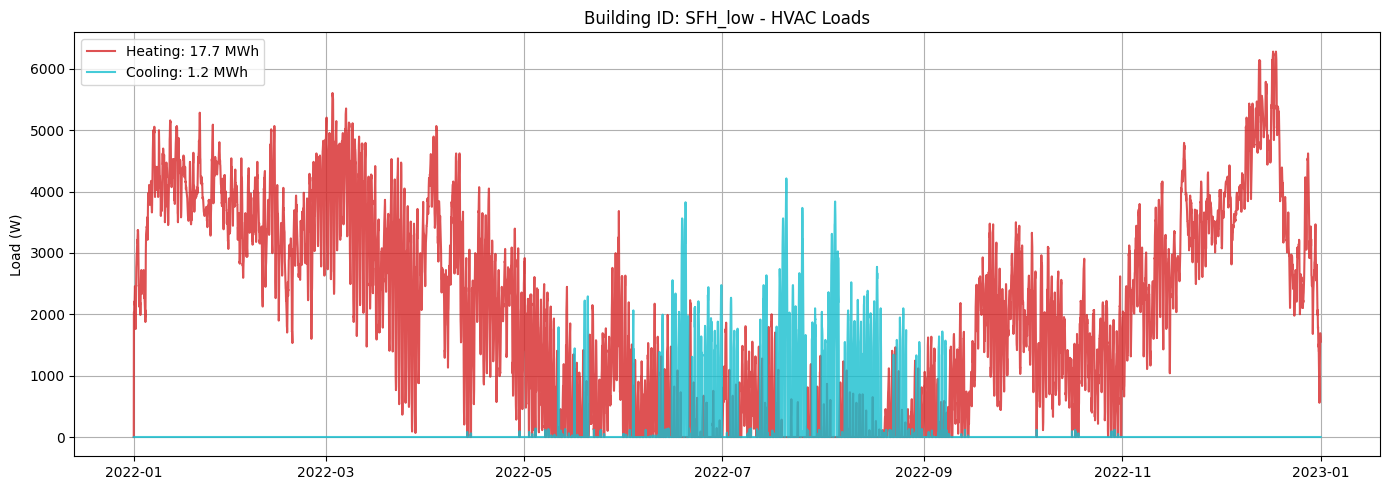

In [16]:
# Figure: Heating and Cooling Loads
fig, ax = plt.subplots(figsize=(14, 5))
heating_MWh = summary.loc[building_id, "heating:demand[Wh]"] / 1e6
cooling_MWh = summary.loc[building_id, "cooling:demand[Wh]"] / 1e6
(line1,) = ax.plot(
    building_data.index,
    building_data["heating:load[W]"],
    label=f"Heating: {heating_MWh:.1f} MWh",
    color="tab:red",
    alpha=0.8,
)
(line2,) = ax.plot(
    building_data.index,
    building_data["cooling:load[W]"],
    label=f"Cooling: {cooling_MWh:.1f} MWh",
    color="tab:cyan",
    alpha=0.8,
)
# Create the combined legend in the upper left corner
ax.set_ylabel("Load (W)")
ax.set_title(f"Building ID: {building_id} - HVAC Loads")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

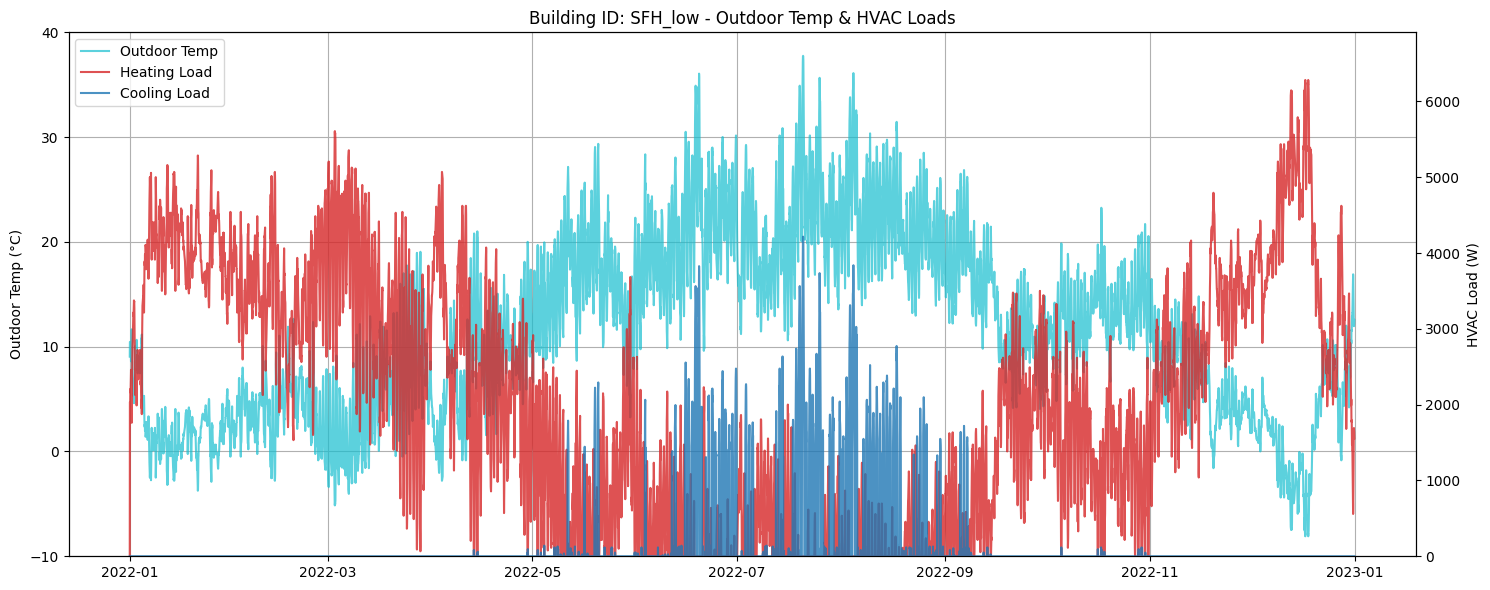

In [17]:
# Figure: Outdoor Temperature with Heating & Cooling Loads
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot outdoor temperature on left y-axis
air_temp = data["weather"][f"{Cols.TEMP_AIR}@2m"]
ax1.plot(building_data.index, air_temp
         , label="Outdoor Temp", color="tab:cyan", alpha=0.7)

ax1.set_ylabel("Outdoor Temp (°C)")
ax1.set_ylim(air_temp.min().round() - 2, air_temp.max().round() + 2)

# Create second y-axis for loads
ax2 = ax1.twinx()
ax2.plot(building_data.index, building_data["heating:load[W]"], label="Heating Load", color="tab:red", alpha=0.8)
ax2.plot(building_data.index, building_data["cooling:load[W]"], label="Cooling Load", color="tab:blue", alpha=0.8)
ax2.set_ylabel("HVAC Load (W)")
ax2.set_ylim(
    min(building_data["heating:load[W]"].min(), building_data["cooling:load[W]"].min()) * 1.1,
    max(building_data["heating:load[W]"].max(), building_data["cooling:load[W]"].max()) * 1.1,
)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title(f"Building ID: {building_id} - Outdoor Temp & HVAC Loads")
ax1.grid(True)
fig.tight_layout()
plt.show()


## Next Steps
You can further explore:
- Adjusting building parameters in `objects.csv`
- Incorporating or excluding additional data (e.g., internal gains, solar gains)
- Investigate how different ventilation strategies impact a buildings energy demand (ventilation)
- Automating analysis for larger building datasets